In [ ]:
import pandas as pd
import numpy as np
dict_data = {
    "years_of_experience":[2,6,10,5,6,9,4,4,12,9,20,1,4,5,9],
    "education_level":["UG","PG","UG","PHD","PHD","UG","DIPLOMA","DIPLOMA","PG","PHD","UG","UG","PG","PHD","PHD"],
    "city":["chennai","kolkata","hyderabad","visag","kolkata","chennai","hyderabad","hyderabad","pune","visag","hyderabad","kolkata","chennai","pune","kolkata"],
    "salary":[800000,600000,400000,600000,1200000,1600000,400000,400000,400000,800000,1200000,400000,600000,300000,500000]
}
data = pd.DataFrame(dict_data)
print(data)

    years_of_experience education_level       city   salary
0                     2              UG    chennai   800000
1                     6              PG    kolkata   600000
2                    10              UG  hyderabad   400000
3                     5             PHD      visag   600000
4                     6             PHD    kolkata  1200000
5                     9              UG    chennai  1600000
6                     4         DIPLOMA  hyderabad   400000
7                     4         DIPLOMA  hyderabad   400000
8                    12              PG       pune   400000
9                     9             PHD      visag   800000
10                   20              UG  hyderabad  1200000
11                    1              UG    kolkata   400000
12                    4              PG    chennai   600000
13                    5             PHD       pune   300000
14                    9             PHD    kolkata   500000


In [ ]:
categorical = data.select_dtypes(include="object").columns

In [ ]:
for i in categorical:
    print(i)
    data[i] = data[i].str.lower()

education_level
city


In [ ]:
numerical = data.select_dtypes(include=[np.number]).columns

In [ ]:
data [numerical] = abs(data[numerical])
data

,years_of_experience,education_level,city,salary
0,2,ug,chennai,800000
1,6,pg,kolkata,600000
2,10,ug,hyderabad,400000
3,5,phd,visag,600000
4,6,phd,kolkata,1200000
5,9,ug,chennai,1600000
6,4,diploma,hyderabad,400000
7,4,diploma,hyderabad,400000
8,12,pg,pune,400000
9,9,phd,visag,800000


In [ ]:
data = data.drop_duplicates()
data

,years_of_experience,education_level,city,salary
0,2,ug,chennai,800000
1,6,pg,kolkata,600000
2,10,ug,hyderabad,400000
3,5,phd,visag,600000
4,6,phd,kolkata,1200000
5,9,ug,chennai,1600000
6,4,diploma,hyderabad,400000
8,12,pg,pune,400000
9,9,phd,visag,800000
10,20,ug,hyderabad,1200000


In [ ]:
data.loc[2,'years_of_experience'] = np.nan
data.loc[6,'years_of_experience'] = np.nan
data.loc[4,'education_level'] = np.nan
data.loc[10,'education_level'] = np.nan
data.loc[11,'city'] = np.nan
data.loc[13,'city'] = np.nan
data.loc[3,'salary'] = np.nan
data.loc[14,'salary'] = np.nan
data

,years_of_experience,education_level,city,salary
0,2.0,ug,chennai,800000.0
1,6.0,pg,kolkata,600000.0
2,NaN,ug,hyderabad,400000.0
3,5.0,phd,visag,NaN
4,6.0,NaN,kolkata,1200000.0
5,9.0,ug,chennai,1600000.0
6,NaN,diploma,hyderabad,400000.0
8,12.0,pg,pune,400000.0
9,9.0,phd,visag,800000.0
10,20.0,NaN,hyderabad,1200000.0


In [ ]:
for i in categorical:
    data[i].fillna(data[i].mode()[0],inplace=True)
for i in numerical:
    data[i].fillna(data[i].mean(),inplace=True)

/tmp/ipykernel_1554/817767011.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[i].fillna(data[i].mode()[0],inplace=True)
/tmp/ipykernel_1554/817767011.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[i].fillna(data[i].mode()[0],inplace=True)
/tmp/ipykernel_1554/817767011.py:4: FutureWarning: A value is trying to be set on a cop

In [ ]:
data_one = pd.get_dummies(data,columns=categorical,dtype=int)
data_one

,years_of_experience,salary,education_level_diploma,education_level_pg,education_level_phd,education_level_ug,city_chennai,city_hyderabad,city_kolkata,city_pune,city_visag
0,2.000000,800000.0,0,0,0,1,1,0,0,0,0
1,6.000000,600000.0,0,1,0,0,0,0,1,0,0
2,7.333333,400000.0,0,0,0,1,0,1,0,0,0
3,5.000000,725000.0,0,0,1,0,0,0,0,0,1
4,6.000000,1200000.0,0,0,1,0,0,0,1,0,0
5,9.000000,1600000.0,0,0,0,1,1,0,0,0,0
6,7.333333,400000.0,1,0,0,0,0,1,0,0,0
8,12.000000,400000.0,0,1,0,0,0,0,0,1,0
9,9.000000,800000.0,0,0,1,0,0,0,0,0,1
10,20.000000,1200000.0,0,0,1,0,0,1,0,0,0


In [ ]:
from sklearn.feature_selection import mutual_info_regression
X = data_one.drop('salary',axis=1)
Y = data_one['salary']
X = pd.get_dummies(X, drop_first=True)
mi = mutual_info_regression(X, Y, random_state=42)
feature_scores = pd.Series(mi, index=X.columns)
feature_scores = feature_scores.sort_values(ascending=False)
print("Mutual Information Scores:")
print(feature_scores)

Mutual Information Scores:
education_level_phd        0.130958
education_level_pg         0.118590
city_hyderabad             0.041209
city_kolkata               0.001190
education_level_diploma    0.000000
years_of_experience        0.000000
city_chennai               0.000000
education_level_ug         0.000000
city_pune                  0.000000
city_visag                 0.000000
dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
scaler = StandardScaler()
x_copy = X.copy()
x_scaled = scaler.fit_transform(x_copy)

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

data_pca = pd.DataFrame(data=x_pca, columns=['PC1', 'PC2'])
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
print("\nFirst 5 rows of PCA Components:")
print(data_pca.head())

Explained Variance Ratio: [0.26284202 0.20105401]

First 5 rows of PCA Components:
        PC1       PC2
0  2.628874  0.225197
1 -0.289480 -1.852635
2  0.654468  1.984223
3 -1.371358 -0.422909
4 -1.274591 -0.955244


In [ ]:
def experience_category(exp):
  if exp<3:
    return "Junior"
  elif exp>=3 and exp<=6:
    return "Mid"
  else:
    return "Senior"
data['Experience_Category'] = data['years_of_experience'].apply(experience_category)
data

/tmp/ipykernel_1554/881039350.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Experience_Category'] = data['years_of_experience'].apply(experience_category)


,years_of_experience,education_level,city,salary,Experience_Category
0,2.000000,ug,chennai,800000.0,Junior
1,6.000000,pg,kolkata,600000.0,Mid
2,7.333333,ug,hyderabad,400000.0,Senior
3,5.000000,phd,visag,725000.0,Mid
4,6.000000,phd,kolkata,1200000.0,Mid
5,9.000000,ug,chennai,1600000.0,Senior
6,7.333333,diploma,hyderabad,400000.0,Senior
8,12.000000,pg,pune,400000.0,Senior
9,9.000000,phd,visag,800000.0,Senior
10,20.000000,phd,hyderabad,1200000.0,Senior


/tmp/ipykernel_1554/563523455.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['log_salary'] = np.log(data['salary'])


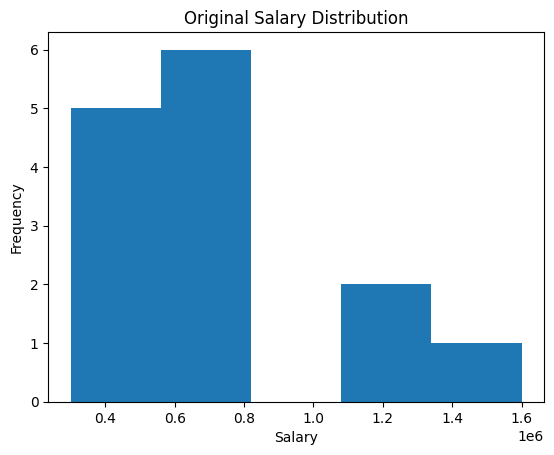

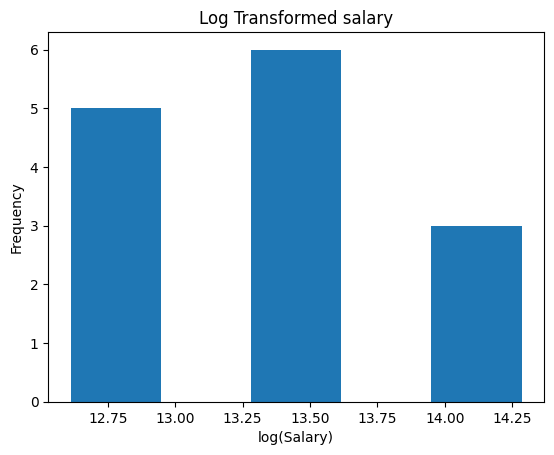

In [ ]:
import matplotlib.pyplot as plt
data['log_salary'] = np.log(data['salary'])
plt.hist(data['salary'],bins=5)
plt.title('Original Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

plt.hist(data['log_salary'],bins=5)
plt.title('Log Transformed salary')
plt.xlabel('log(Salary)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_copy = X.copy()     # X comes from your mutual information step
x_scaled = scaler.fit_transform(x_copy)

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Split the scaled dataset
X_train, X_test = train_test_split(x_scaled, test_size=0.2, random_state=42)

# Define dimensions
input_dim = X_train.shape[1]
encoding_dim = 2   # compress features to 2

# Input layer
input_layer = Input(shape=(input_dim,))

# Encoder
encoded = Dense(8, activation='relu')(input_layer)
encoded = Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(8, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

# Autoencoder model
autoencoder = Model(inputs=input_layer, outputs=decoded)

# Encoder model (for feature extraction)
encoder = Model(inputs=input_layer, outputs=encoded)

# Compile the model
autoencoder.compile(optimizer='adam', loss='mse')

# Train the autoencoder
autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=4,
    validation_data=(X_test, X_test),
    verbose=1
)

# Extract compressed features
learned_features = encoder.predict(x_scaled)

print("Learned Features Shape:", learned_features.shape)
print("\nFirst 5 rows of learned features:")
print(learned_features[:5])

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 1.0239 - val_loss: 1.1896
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 1.0091 - val_loss: 1.1822
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.9986 - val_loss: 1.1759
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.9886 - val_loss: 1.1711
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.9815 - val_loss: 1.1658
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.9734 - val_loss: 1.1609
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.9668 - val_loss: 1.1558
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.9587 - val_loss: 1.1507
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.9526 - val_loss: 1.1466
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.9455 - val_loss: 1.1429
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.9394 - val_loss: 1.1396
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.9339 - val_loss: 1.1368
